In [3]:
import os
import cv2
import gc
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.models import Model

In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

X = []
Y = []

IMG_SIZE = 64

base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

# ============================================================
# LOAD IMAGES
# ============================================================

for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

        Y.append(label)

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.array(X, dtype='float16')

Y = np.array(Y)

# Normalize
X = X / 255.0

print("Dataset Shape :", X.shape)

# ============================================================
# FLATTEN IMAGES
# ============================================================

X_flatten = X.reshape(X.shape[0], -1)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(

    X_flatten,
    Y,

    test_size=0.2,

    stratify=Y,

    random_state=42
)

print("Training Shape :", X_train_full.shape)

print("Testing Shape :", X_test.shape)

Dataset Shape : (2870, 64, 64, 3)
Training Shape : (2296, 12288)
Testing Shape : (574, 12288)



ORIGINAL XGBOOST WITH 20% DATA
Accuracy : 0.7561
F1 Score : 0.7533

ORIGINAL XGBOOST WITH 40% DATA
Accuracy : 0.8328
F1 Score : 0.8329

ORIGINAL XGBOOST WITH 60% DATA
Accuracy : 0.8624
F1 Score : 0.8617

ORIGINAL XGBOOST WITH 80% DATA
Accuracy : 0.8920
F1 Score : 0.8921


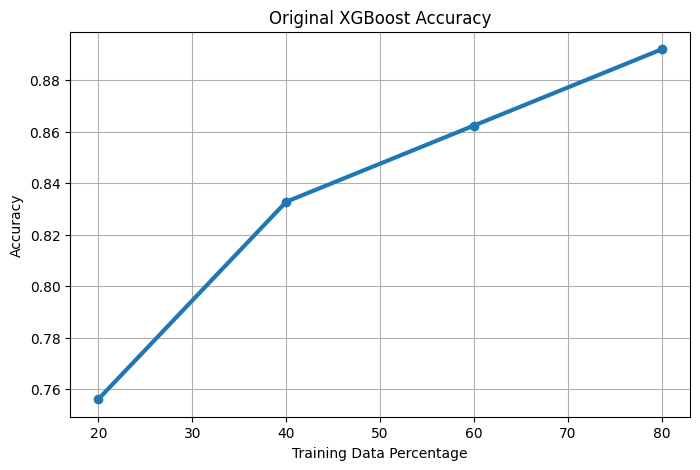

In [5]:
# ============================================================
# ORIGINAL XGBOOST
# ============================================================

percentages = [20,40,60,80]

accuracies_xgb = []

for pct in percentages:

    print("\n================================================")
    print(f"ORIGINAL XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_full) * (pct/100))

    X_train = X_train_full[:subset_size]

    y_train = y_train_full[:subset_size]

    # ========================================================
    # MODEL
    # ========================================================

    xgb_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='multi:softmax',

        num_class=4,

        eval_metric='mlogloss',

        random_state=42
    )

    # Train
    xgb_model.fit(X_train, y_train)

    # Predict
    y_pred = xgb_model.predict(X_test)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred, average='weighted')

    accuracies_xgb.append(accuracy)

    print(f"Accuracy : {accuracy:.4f}")

    print(f"F1 Score : {f1:.4f}")

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_xgb,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Original XGBoost Accuracy")

plt.grid(True)

plt.show()


PCA + XGBOOST WITH 20% DATA
Accuracy : 0.6585
F1 Score : 0.6496

PCA + XGBOOST WITH 40% DATA
Accuracy : 0.7021
F1 Score : 0.6950

PCA + XGBOOST WITH 60% DATA
Accuracy : 0.7439
F1 Score : 0.7415

PCA + XGBOOST WITH 80% DATA
Accuracy : 0.7683
F1 Score : 0.7654


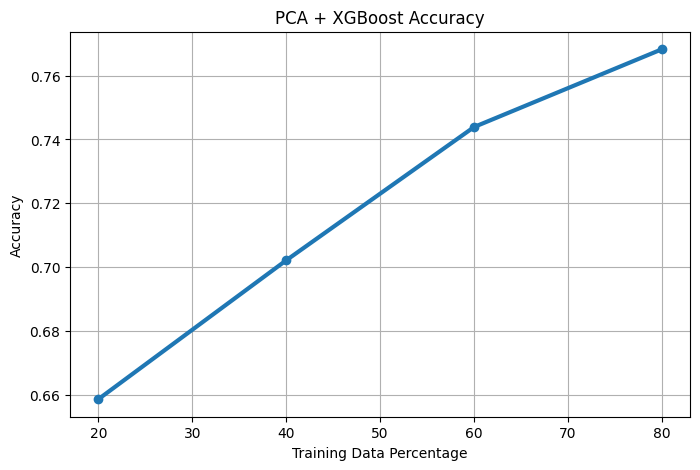

In [7]:
# ============================================================
# PCA + XGBOOST
# ============================================================

percentages = [20,40,60,80]

accuracies_pca = []

for pct in percentages:

    print("\n================================================")
    print(f"PCA + XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_full) * (pct/100))

    X_train = X_train_full[:subset_size]

    y_train = y_train_full[:subset_size]

    # ========================================================
    # PCA
    # ========================================================

    pca = PCA(n_components=50)

    X_train_pca = pca.fit_transform(X_train)

    X_test_pca = pca.transform(X_test)

    # ========================================================
    # MODEL
    # ========================================================

    pca_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='multi:softmax',

        num_class=4,

        eval_metric='mlogloss',

        random_state=42
    )

    # Train
    pca_model.fit(X_train_pca, y_train)

    # Predict
    y_pred_pca = pca_model.predict(X_test_pca)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy_pca = accuracy_score(y_test, y_pred_pca)

    f1_pca = f1_score(y_test, y_pred_pca, average='weighted')

    accuracies_pca.append(accuracy_pca)

    print(f"Accuracy : {accuracy_pca:.4f}")

    print(f"F1 Score : {f1_pca:.4f}")

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_pca,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("PCA + XGBoost Accuracy")

plt.grid(True)

plt.show()

In [9]:
# ============================================================
# RELOAD IMAGES FOR VGG16
# ============================================================

X_vgg = []
Y_vgg = []

IMG_SIZE_VGG = 224

for cls, label in classes.items():

    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE_VGG, IMG_SIZE_VGG))

        img = preprocess_input(img)

        X_vgg.append(img)

        Y_vgg.append(label)

X_vgg = np.array(X_vgg, dtype='float16')

Y_vgg = np.array(Y_vgg)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_vgg_full, X_test_vgg, y_train_vgg_full, y_test_vgg = train_test_split(

    X_vgg,
    Y_vgg,

    test_size=0.2,

    stratify=Y_vgg,

    random_state=42
)

# ============================================================
# LOAD VGG16
# ============================================================

base_model = VGG16(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Feature extractor
feature_extractor = Model(

    inputs=base_model.input,

    outputs=base_model.output
)

# ============================================================
# EXTRACT TEST FEATURES
# ============================================================

test_features = feature_extractor.predict(X_test_vgg)

test_features = test_features.reshape(
    test_features.shape[0],
    -1
)

print("Test Feature Shape :", test_features.shape)

I0000 00:00:1779084361.162055      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1779084364.124548     142 service.cc:152] XLA service 0x78220e5c65d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779084364.124603     142 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779084364.274903     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step

I0000 00:00:1779084371.889583     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 437ms/step
Test Feature Shape : (574, 25088)



VGG16 + XGBOOST WITH 20% DATA
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step
Accuracy : 0.7805
F1 Score : 0.7784

VGG16 + XGBOOST WITH 40% DATA
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step
Accuracy : 0.8449
F1 Score : 0.8440

VGG16 + XGBOOST WITH 60% DATA
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step
Accuracy : 0.8432
F1 Score : 0.8416

VGG16 + XGBOOST WITH 80% DATA
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step
Accuracy : 0.8711
F1 Score : 0.8710


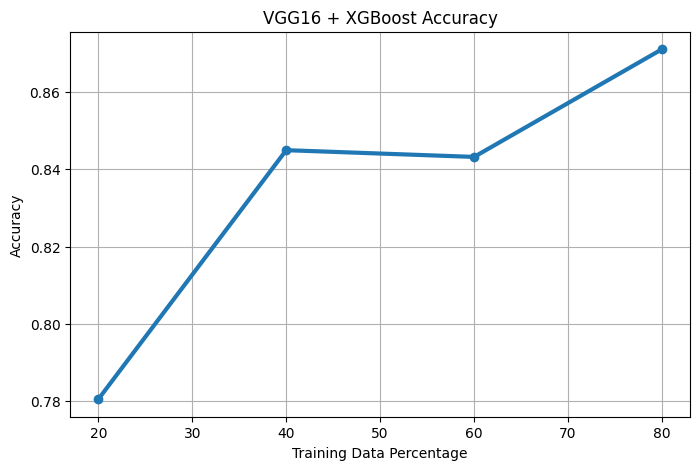

In [10]:
# ============================================================
# VGG16 + XGBOOST
# ============================================================

percentages = [20,40,60,80]

accuracies_vgg = []

for pct in percentages:

    print("\n================================================")
    print(f"VGG16 + XGBOOST WITH {pct}% DATA")
    print("================================================")

    subset_size = int(len(X_train_vgg_full) * (pct/100))

    X_train_vgg = X_train_vgg_full[:subset_size]

    y_train_vgg = y_train_vgg_full[:subset_size]

    # ========================================================
    # FEATURE EXTRACTION
    # ========================================================

    train_features = feature_extractor.predict(X_train_vgg)

    train_features = train_features.reshape(
        train_features.shape[0],
        -1
    )

    # ========================================================
    # MODEL
    # ========================================================

    vgg_model = XGBClassifier(

        n_estimators=30,

        max_depth=6,

        learning_rate=0.1,

        objective='multi:softmax',

        num_class=4,

        eval_metric='mlogloss',

        random_state=42
    )

    # Train
    vgg_model.fit(train_features, y_train_vgg)

    # Predict
    y_pred_vgg = vgg_model.predict(test_features)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy_vgg = accuracy_score(y_test_vgg, y_pred_vgg)

    f1_vgg = f1_score(y_test_vgg, y_pred_vgg, average='weighted')

    accuracies_vgg.append(accuracy_vgg)

    print(f"Accuracy : {accuracy_vgg:.4f}")

    print(f"F1 Score : {f1_vgg:.4f}")

# ============================================================
# ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    accuracies_vgg,
    marker='o',
    linewidth=3
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("VGG16 + XGBoost Accuracy")

plt.grid(True)

plt.show()

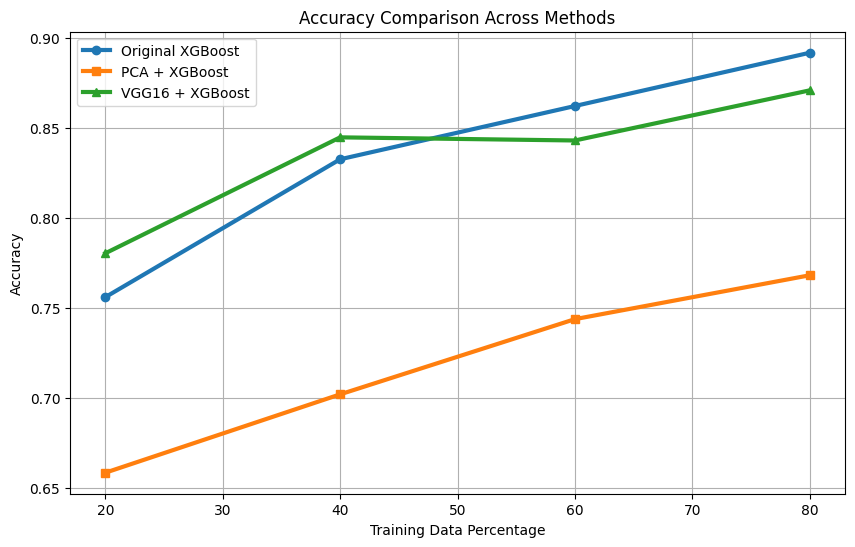


FINAL ACCURACY COMPARISON

20% Training Data
Original XGBoost : 0.7561
PCA + XGBoost    : 0.6585
VGG16 + XGBoost  : 0.7805

40% Training Data
Original XGBoost : 0.8328
PCA + XGBoost    : 0.7021
VGG16 + XGBoost  : 0.8449

60% Training Data
Original XGBoost : 0.8624
PCA + XGBoost    : 0.7439
VGG16 + XGBoost  : 0.8432

80% Training Data
Original XGBoost : 0.8920
PCA + XGBoost    : 0.7683
VGG16 + XGBoost  : 0.8711



In [11]:
# ============================================================
# FINAL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    percentages,
    accuracies_xgb,
    marker='o',
    linewidth=3,
    label='Original XGBoost'
)

plt.plot(
    percentages,
    accuracies_pca,
    marker='s',
    linewidth=3,
    label='PCA + XGBoost'
)

plt.plot(
    percentages,
    accuracies_vgg,
    marker='^',
    linewidth=3,
    label='VGG16 + XGBoost'
)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison Across Methods")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n================================================")
print("FINAL ACCURACY COMPARISON")
print("================================================\n")

for i in range(len(percentages)):

    print(f"{percentages[i]}% Training Data")

    print(f"Original XGBoost : {accuracies_xgb[i]:.4f}")

    print(f"PCA + XGBoost    : {accuracies_pca[i]:.4f}")

    print(f"VGG16 + XGBoost  : {accuracies_vgg[i]:.4f}")

    print()